# 第 6 章：文本分类的微调

In [49]:
from importlib.metadata import version

pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.2.6
tiktoken version: 0.12.0
torch version: 2.7.1+cu118
tensorflow version: 2.21.0
pandas version: 2.3.3


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/01.webp" width=500px>

### 6.1 不同类别的微调

- 微调语言模型的最常见方法是指令微调和分类微调
- 指令微调，如下所示，是下一章的主题
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp" width=500px>

- 本章介绍的主题分类微调，对于有机器学习背景的读者来说应该很熟悉——这个过程类似于训练卷积神经网络来识别手写数字。
- 在分类微调中，模型会输出固定数量的类别标签（例如"垃圾邮件"和"非垃圾邮件"）。
- 分类微调模型只能预测训练时见过的类别（如"垃圾邮件"或"非垃圾邮件"），而指令微调模型通常能够执行多种任务。
- 我们可以将分类微调模型看作高度专业化的模型；实际上，创建专用模型比构建能在多个任务上都表现良好的通用模型要容易得多

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp" width=400px>

### 6.2 准备数据集

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp" width=500px>

我们使用垃圾信息和非垃圾信息组成的数据集来微调LLM，使其能够对他们进行分类。


In [50]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [51]:
# 读取数据
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [52]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [53]:
# Listing 6.2 Creating a balanced dataset
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]                                 #A
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)      #B
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])              #C
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())


#A 统计垃圾短信的实例数量
#B 随机抽取正常邮件实例，使其数量与垃圾短信实例相同。
#C 将正常短信子集与垃圾短信合并


Label
ham     747
spam    747
Name: count, dtype: int64


- 接下来，我们将字符串类标签“ham”和“spam”更改为整数类标签0和1：

In [54]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [55]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- 现在让我们定义一个函数，将数据集随机划分为训练、验证和测试子集
- 70%用于训练，10%用于验证，20%用于测试。这些比例是机器学习中用于训练、调整和评估模型的常见划分比例

In [56]:
# Listing 6.3 Splitting the dataset
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)     #A

    train_end = int(len(df) * train_frac)                               #B
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]                                           #C
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)  #D


#A 将整个 DataFrame 随机打乱
#B 计算数据分割的索引
#C 分割 DataFrame
#D 测试集默认大小为 0.2（即剩余部分）


此外，我们将数据集保存为 CSV 文件，以便后续复用

In [57]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)


## 6.3 创建数据加载器

- 请注意，message的长度各不相同。如果我们想在一个批次中组合多个训练示例，必须采取以下两种策略之一：
  1. 将所有消息截断为数据集中最短消息的长度
  2. 将所有消息填充到数据集（或批次）中最长消息的长度

  我们选择方案 2，将所有消息填充到数据集中最长消息的长度。为此，我们使用 `<|endoftext|>` 作为填充标记，如第 2 章所述。
 <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp" width=500px>



In [58]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 下面的 `SpamDataset` 类会找出训练数据集中最长的序列，并向其他序列添加填充标记，使其长度与该最长序列对齐。


In [59]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [60]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


- 我们还将验证集和测试集填充到与最长训练序列相同的长度
- 注意：如果验证集或测试集中有比最长训练样本更长的消息，`SpamDataset` 代码中的 `encoded_text[:self.max_length]` 会将其截断
- 这种截断行为是完全可选的。如果我们在处理验证集和测试集时设置 `max_length=None`，程序也能正常工作（只是不会进行截断）


In [61]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp" width=500px>

In [62]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- 作为验证步骤，我们迭代数据加载器并确保每个批次包含 8 个训练示例，其中每个训练示例包含 120 个标记

In [63]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [64]:
# 每个数据集的批次
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


### 6.4 使用预训练权重初始化模型
- 在本节中，我们初始化上一章中使用的预训练模型
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/08.webp" width=500px>

In [65]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [66]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [67]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- 在我们将模型微调为分类器之前，让我们看看模型是否已经可以通过提示对垃圾邮件进行分类

In [68]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=30,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive


### 6.5 添加分类头

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp" width=500px>

我们将修改预训练的模型架构，在其顶部添加一个分类头。分类头是一个简单的线性层，它将模型的输出（即最后一个隐藏状态）映射到类别标签（在我们的例子中是0和1）。我们将冻结预训练模型的部分权重，这样在微调过程中它们就不会更新。

In [69]:
# 打印并观察模型结构
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [70]:
# 冻结所有的预训练权重
for param in model.parameters():
    param.requires_grad = False

- 接下来，我们替换输出层 `model.out_head`。原始的输出层将输入映射到 50,257 维（对应词汇表大小）
- 由于我们要对二元分类任务进行微调（预测"垃圾邮件"和"非垃圾邮件"两个类别），需要将输出层替换为只输出 2 维的新层。新层默认是可训练的
- 注意：我们使用 `BASE_CONFIG["emb_dim"]`（在 `gpt2-small (124M)` 模型中等于 768）作为输入维度，这样代码更通用，可以适配不同大小的模型


In [71]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

- 从技术上讲，只训练输出层就足够了
- 但是加上最后一个layerNorm和Transformer块的权重通常会产生更好的结果，因为它们直接影响输出层的输入
- 因此，我们还将最后一个layerNorm和Transformer块的权重设置为可训练的

In [72]:
# 允许最后一个layerNorm和Transformer块的权重更新
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

In [73]:
# 把一个简单的输入样例转换成张量
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [74]:
# 之前章节的模型输出维度是 (batch_size, num_tokens, vocab_size)，现在我们期望输出维度是 (batch_size, num_tokens, num_classes)
# 也就是说，输出的最后一个维度现在应该是类别数量（2），而不是词汇表大小（50,257）
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


- 正如前几章讨论的那样，模型会为每个输入标记生成一个输出向量
- 由于我们向模型提供了一个包含 4 个标记的文本样本，因此输出由 4 个二维向量组成
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp" width=500px>
- 在第 3 章中，我们讨论了注意力机制，它将每个输入标记与其他标记建立连接
- 我们还介绍了类 GPT 模型中使用的因果注意力掩码（causal attention mask），它让当前标记只能关注自身及之前的标记位置
- 基于这种因果注意力机制，最后一个标记（第 4 个）包含了最丰富的信息，因为它是唯一能够"看到"所有其他标记的标记
- 因此，我们对最后一个标记特别感兴趣，将针对垃圾邮件分类任务对其进行微调



In [75]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp" width=200px>

### 6.6 计算分类损失和准确率

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/13.webp" width=300px>

- 在解释损失计算之前，我们先简单看一下模型输出是如何转化为类标签的

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp" width=600px>

In [76]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


- 与第 5 章类似，我们先通过 `softmax` 函数将输出（logits）转换为概率分数，再通过 `argmax` 函数获取概率最大值对应的索引位置


In [77]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [78]:
# softmax其实可以省略，因为argmax在单调变换下不变
label = torch.argmax(outputs[:, -1, :], dim=-1)
print("Class label:", label.item())

Class label: 1


- 我们可以应用这个概念来计算分类精度，即数据集中正确预测的百分比
- 为了计算分类精度，我们将前面基于 `argmax` 的预测代码应用于数据集中的所有样本，并统计正确预测的比例，如下所示：


In [79]:
# 下面的函数计算数据加载器中模型的分类准确率。它迭代数据加载器中的批次，使用模型进行预测，并统计正确预测的数量与总样本数量的比例。
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- 让我们应用该函数来计算不同数据集的分类精度：

In [80]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # 使用 PyTorch 2.9 或更高版本以获得稳定的 MPS 结果
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model.to(device)  # nn.Module 类不需要赋值操作 model = model.to(device)

torch.manual_seed(123)  # 由于训练数据加载器的随机打乱，设置种子以保证可复现性

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")


Device: cuda
Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


- 在开始微调（训练）之前，我们必须首先定义训练期间要优化的损失函数
- 我们的目标是最大化模型的垃圾邮件分类准确率，但分类准确率不是可微函数，无法直接用于梯度下降
- 因此，我们转而最小化交叉熵损失，作为最大化分类准确率的替代目标
- 这里的 `calc_loss_batch` 函数与第 5 章中的相同，只是我们只关注最后一个标记的输出 `model(input_batch)[:, -1, :]`，而不是所有标记的输出 `model(input_batch)`


In [81]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

# 计算整个数据加载器的平均损失（与之前一致）
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [82]:
with torch.no_grad():  # 禁用梯度跟踪以提高效率，因为此时还未开始训练
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")


Training loss: 2.453
Validation loss: 2.583
Test loss: 2.322


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/10.webp" width=400px>

### 6.7 使用监督数据微调模型
- 在本节中，我们定义并使用训练函数来提高模型的分类准确率
- 下面的 `train_classifier_simple` 函数实际上与第 5 章中用于预训练模型的 `train_model_simple` 函数相同
- 唯一的两个区别是：
  1. 我们现在跟踪已处理的训练样本数量（`examples_seen`），而不是标记数量
  2. 在每个 epoch 后计算准确率，而不是像之前那样在每个 epoch 后打印示例文本

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp" width=500px>

In [83]:
# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

# 与第 5 章中的 `train_model_simple` 基本相同
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,eval_freq,eval_iter):
    # 初始化列表以跟踪损失和已处理的样本数
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # 主训练循环
    for epoch in range(num_epochs):
        model.train()  # 设置模型为训练模式

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # 重置上一批次的损失梯度
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # 计算损失梯度
            optimizer.step()  # 使用损失梯度更新模型权重
            examples_seen += input_batch.shape[0]  # 新增：跟踪样本数而非标记数
            global_step += 1

            # 可选的评估步骤
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # 在每个 epoch 后计算准确率
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [84]:
# 开始训练
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.99 mi

- 与第 5 章类似，我们使用 matplotlib 绘制训练集和验证集的损失函数

In [85]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 绘制训练集和验证集的损失随 epoch 变化的曲线
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # 创建第二个 x 轴以显示已处理的样本数
    ax2 = ax1.twiny()  # 创建一个共享 y 轴的第二个 x 轴
    ax2.plot(examples_seen, train_values, alpha=0)  # 不可见的绘图，用于对齐刻度
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # 调整布局以留出空间
    plt.savefig(f"{label}-plot.pdf")
    plt.show()


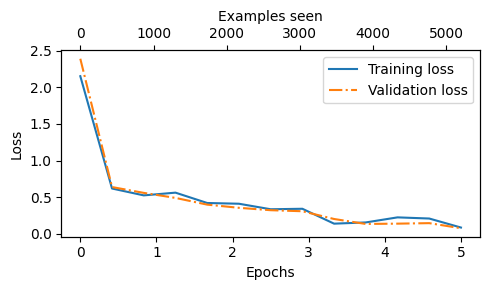

In [86]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

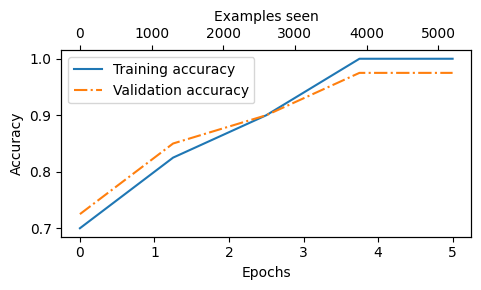

In [87]:
#绘制准确率的图像
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- 从上面的准确率图可以看出，模型在第 4 和第 5 个 epoch 后达到了相对较高的训练和验证准确率
- 但需要注意的是，我们之前在训练函数中设置了 `eval_iter=5`，这意味着我们只评估了训练集和验证集中部分样本的性能（仅 5 个批次）
- 下面，我们可以计算整个训练集、验证集和测试集上的完整性能指标


In [88]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- 我们可以看到，训练集和验证集的性能几乎相同
- 然而，测试集性能略低，这表明模型对训练数据存在轻微的过拟合，验证集也被用于调整一些超参数（如学习率）
- 这种现象是正常的，但可以通过增加模型的 dropout 率（`drop_rate`）或优化器设置中的权重衰减（`weight_decay`）来进一步缩小这种差距


### 6.8 使用 LLM 作为垃圾邮件分类器

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/18.webp" width=500px>

- 最后，让我们实际使用微调后的 GPT 模型
- 下面的 `classify_review` 函数实现了与之前 `SpamDataset` 类似的数据预处理步骤
- 该函数会返回模型预测的整数类别标签，以及对应的类别名称


In [89]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # 准备模型输入
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # 注意：书中此处原误写为 pos_emb.weight.shape[1]
    # 虽不会导致代码崩溃，但会造成不必要的截断（截断至 768 而非 1024）

    # 如果序列过长则进行截断
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "必须指定 max_length。如果想使用模型的完整上下文长度，"
        "请传入 max_length=model.pos_emb.weight.shape[0]。"
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) 超过了模型支持的上下文长度 ({supported_context_length})。"
    )
    # 或者，可以使用以下更健壮的版本，能更好地处理 max_length=None 的情况
    # max_len = min(max_length, supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]

    # 填充序列至最长长度
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0)  # 添加批次维度

    # 模型推理
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # 最后一个输出标记的 logits
    predicted_label = torch.argmax(logits, dim=-1).item()

    # 返回分类结果
    return "spam" if predicted_label == 1 else "not spam"


In [90]:
# 测试一下
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [91]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [92]:
# 保存模型
torch.save(model.state_dict(), "review_classifier.pth")

In [94]:
# 在新会话中可以这样加载模型

model2 = GPTModel(BASE_CONFIG)

# 关键步骤：替换输出层为分类头（与保存的模型结构一致）
num_classes = 2
model2.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

# 解冻最后Transformer块和LayerNorm（如果之前冻结过）
for param in model2.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model2.final_norm.parameters():
    param.requires_grad = True

# 现在可以加载微调后的权重了
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model2.load_state_dict(model_state_dict)

# 设置为评估模式
model2.to(device)
model2.eval()


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [95]:
# 使用加载的model2
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model2, tokenizer, device, max_length=train_dataset.max_length
))

not spam
